In [ ]:
!nvidia-smi

Mon Feb 16 13:41:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import ultralytics
print(ultralytics.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
8.4.14


In [ ]:
!yolo help


    Arguments received: ['yolo', 'help']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of ['obb', 'classify', 'pose', 'segment', 'detect']
                MODE (required) is one of ['predict', 'track', 'train', 'export', 'benchmark', 'val']
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' that override defaults.
                    See all ARGS at https://docs.ultralytics.com/usage/cfg or with 'yolo cfg'

    1. Train a detection model for 10 epochs with an initial learning_rate of 0.01
        yolo train data=coco8.yaml model=yolo26n.pt epochs=10 lr0=0.01

    2. Predict a YouTube video using a pretrained segmentation model at image size 320:
        yolo predict model=yolo26n-seg.pt source='https://youtu.be/LNwODJXcvt4' imgsz=320

    3. Validate a pretrained detection model at batch-size 1 and image size 640:
        yolo val model=yolo26n.pt data=coco8.yaml batc

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

In [ ]:
!git clone https://github.com/pridwimnjha/Multi-class-waste-detection.git
%cd Multi-class-waste-detection

Cloning into 'Multi-class-waste-detection'...
remote: Enumerating objects: 3524, done.
remote: Total 3524 (delta 0), reused 0 (delta 0), pack-reused 3524 (from 2)
Receiving objects: 100% (3524/3524), 150.59 MiB | 44.15 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/Multi-class-waste-detection


In [ ]:
!ls images

train  val


In [ ]:
!ls labels

train  val


In [ ]:
%%writefile dataset.yaml
path: /content/Multi-class-waste-detection
train: images/train
val: images/val

nc: 6
names: ['glass_bottle', 'metal_can', 'plastic_bag', 'plastic_bottle', 'plastic_container', 'plastic_wrapper']


Writing dataset.yaml


In [ ]:
!yolo detect train model=yolo11n.pt data=dataset.yaml epochs=85 imgsz=768 batch=16


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=85, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, 

In [ ]:
!wget "https://github.com/pridwimnjha/Multi-class-waste-detection/raw/main/test.zip"


--2026-02-16 14:38:31--  https://github.com/pridwimnjha/Multi-class-waste-detection/raw/main/test.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/pridwimnjha/Multi-class-waste-detection/main/test.zip [following]
--2026-02-16 14:38:32--  https://raw.githubusercontent.com/pridwimnjha/Multi-class-waste-detection/main/test.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9301071 (8.9M) [application/zip]
Saving to: ‘test.zip’

test.zip            100%[===================>]   8.87M  --.-KB/s    in 0.06s   

2026-02-16 14:38:32 (156 MB/s) - ‘test.zip’ saved [9301071/9301071]



In [ ]:
!unzip test.zip -d test_images


Archive:  test.zip
   creating: test_images/test/
  inflating: test_images/test/glass_bottle (273).jpg  
  inflating: test_images/test/glass_bottle (274).jpg  
  inflating: test_images/test/glass_bottle (275).jpg  
  inflating: test_images/test/glass_bottle (276).jpg  
  inflating: test_images/test/glass_bottle (277).jpg  
  inflating: test_images/test/glass_bottle (278).jpg  
  inflating: test_images/test/glass_bottle (279).jpg  
  inflating: test_images/test/glass_bottle (280).jpg  
  inflating: test_images/test/glass_bottle (281).jpg  
  inflating: test_images/test/glass_bottle (282).jpg  
  inflating: test_images/test/glass_bottle (283).jpg  
  inflating: test_images/test/glass_bottle (284).jpg  
  inflating: test_images/test/glass_bottle (285).jpg  
  inflating: test_images/test/glass_bottle (286).jpg  
  inflating: test_images/test/glass_bottle (287).jpg  
  inflating: test_images/test/glass_bottle (288).jpg  
  inflating: test_images/test/glass_bottle (289).jpg  
  inflating: te

In [ ]:
!ls test_images


test


In [ ]:
!ls test_images/test


'glass_bottle (273).jpg'  'plastic_bag (329).jpg'
'glass_bottle (274).jpg'  'plastic_bag (330).jpg'
'glass_bottle (275).jpg'  'plastic_bag (331).jpg'
'glass_bottle (276).jpg'  'plastic_bag (332).jpg'
'glass_bottle (277).jpg'  'plastic_bag (333).jpg'
'glass_bottle (278).jpg'  'plastic_bag (334).jpg'
'glass_bottle (279).jpg'  'plastic_bag (335).jpg'
'glass_bottle (280).jpg'  'plastic_bag (336).jpg'
'glass_bottle (281).jpg'  'plastic_bag (337).jpg'
'glass_bottle (282).jpg'  'plastic_bag (338).jpg'
'glass_bottle (283).jpg'  'plastic_bag (339).jpg'
'glass_bottle (284).jpg'  'plastic_bag (340).jpg'
'glass_bottle (285).jpg'  'plastic_bag (341).jpg'
'glass_bottle (286).jpg'  'plastic_bag (342).jpg'
'glass_bottle (287).jpg'  'plastic_bottle (273).jpg'
'glass_bottle (288).jpg'  'plastic_bottle (274).jpg'
'glass_bottle (289).jpg'  'plastic_bottle (275).jpg'
'glass_bottle (290).jpg'  'plastic_bottle (276).jpg'
'glass_bottle (291).jpg'  'plastic_bottle (277).jpg'
'glass_bottle (292).jpg'  'plastic_

In [ ]:
!yolo detect predict \
model=runs/detect/train/weights/best.pt \
source=test_images/test \
imgsz=640 \
conf=0.25 \
save=True


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs

image 1/355 /content/Multi-class-waste-detection/test_images/test/Plastic_Wrapper (316)-LAPTOP-IDCB80VF.jpg: 448x640 2 plastic_wrappers, 50.7ms
image 2/355 /content/Multi-class-waste-detection/test_images/test/Plastic_Wrapper (322)-LAPTOP-IDCB80VF.jpg: 448x640 1 plastic_wrapper, 7.9ms
image 3/355 /content/Multi-class-waste-detection/test_images/test/Plastic_Wrapper (322).jpg: 448x640 1 plastic_wrapper, 7.5ms
image 4/355 /content/Multi-class-waste-detection/test_images/test/glass_bottle (273).jpg: 640x640 1 glass_bottle, 8.5ms
image 5/355 /content/Multi-class-waste-detection/test_images/test/glass_bottle (274).jpg: 640x640 1 glass_bottle, 7.9ms
image 6/355 /content/Multi-class-waste-detection/test_images/test/glass_bottle (275).jpg: 640x640 1 glass_bottle, 7.9ms
image 7/355 /content/Multi-class-waste-detection/test_images/t

In [ ]:
!ls runs/detect/predict | head


glass_bottle (273).jpg
glass_bottle (274).jpg
glass_bottle (275).jpg
glass_bottle (276).jpg
glass_bottle (277).jpg
glass_bottle (278).jpg
glass_bottle (279).jpg
glass_bottle (280).jpg
glass_bottle (281).jpg
glass_bottle (282).jpg


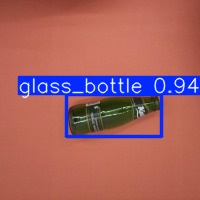

In [ ]:
from IPython.display import Image
Image("runs/detect/predict/glass_bottle (273).jpg")


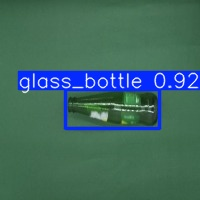

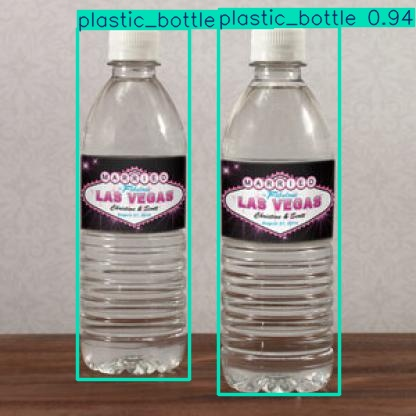

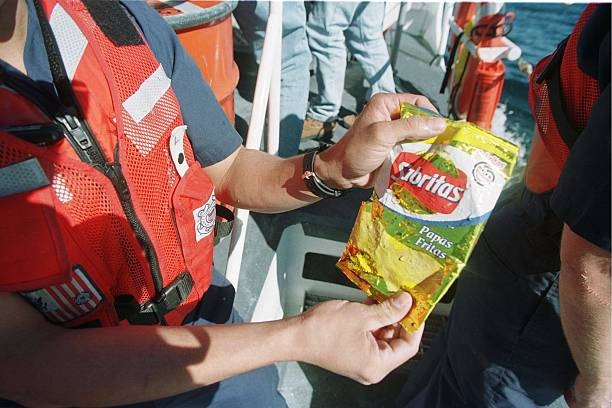

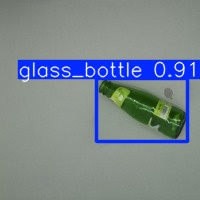

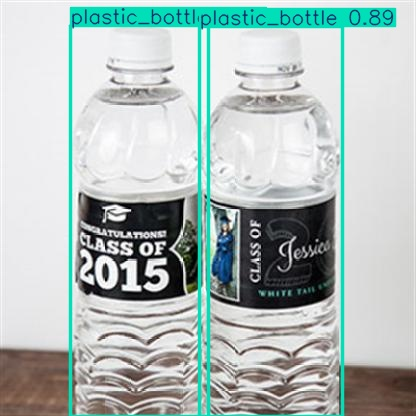

In [ ]:
import os
from IPython.display import Image, display

files = os.listdir("runs/detect/predict")[:5]

for f in files:
    display(Image(os.path.join("runs/detect/predict", f)))


In [ ]:
!pip install gradio


In [ ]:
import gradio as gr
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

def detect(image):
    results = model(image)
    return results[0].plot()

demo = gr.Interface(
    fn=detect,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Image(type="numpy"),
    title="Multi-Class Waste Detection (YOLOv11)",
    description="Upload an image to detect waste objects."
)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://62c8c0645d215005b9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from google.colab import files

files.download("/content/Multi-class-waste-detection/runs/detect/train/weights/best.pt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>